In [38]:

#พื้นที่นำเข้าสิ่งที่ต้องใช้ทั้งหมด
#พื้นฐาน
import numpy as np
import pandas as pd

#ทำ EDA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


นำเข้าข้อมูล

In [4]:
restaurant = pd.read_csv("Restaurant.csv")
restaurant

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,7/11/2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,7/11/2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,7/11/2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,8/11/2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,8/11/2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
249,10709,28-12-2022,Sides & Other,4.99,200.40,Drive-thru,Gift Card,Walter Muller,Berlin
250,10710,29-12-2022,Burgers,12.99,754.43,Drive-thru,Gift Card,Walter Muller,Berlin
251,10711,29-12-2022,Chicken Sandwiches,9.95,281.41,Drive-thru,Gift Card,Walter Muller,Berlin
252,10712,29-12-2022,Fries,3.49,630.37,Drive-thru,Gift Card,Walter Muller,Berlin


In [5]:
#ข้อมูลใน csv
restaurant.info()  #แสดงประเภทข้อมูล (Data Types) และจำนวน Non-Null   

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        254 non-null    int64  
 1   Date            254 non-null    str    
 2   Product         254 non-null    str    
 3   Price           254 non-null    float64
 4   Quantity        254 non-null    float64
 5   Purchase Type   254 non-null    str    
 6   Payment Method  254 non-null    str    
 7   Manager         254 non-null    str    
 8   City            254 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 18.0 KB


จากผลลัพธ์การตรวจสอบข้อมูล แสดงให้เห็นว่า
1. ข้อมูลอยู่ในรูป dataframe
2. มีข้อมูลทั้งหมด 254 แถว 10 columns 
3. ข้อมูลแต่ละ Columns ไม่มีข้อมูลใดที่เป็นช่องว่าง
4. Date ถูกเก็บในรูปแบบ str ทำให้ไม่สามารถนำมากรองเป็นวันที่ได้
5. ค่า quantity ถูกเก็บเป็น float แต่จำนวนชิ้นในการขายควรเป็นจำนวณเต็ม

แปลง quantity

In [6]:
restaurant['Quantity'] = restaurant['Quantity'].round().astype(int)
restaurant.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,7/11/2022,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,7/11/2022,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid
2,10454,7/11/2022,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,8/11/2022,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin
4,10456,8/11/2022,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


In [7]:
#ตรวจสอบรูปแบบของข้อมูล Date
restaurant['Date'].sample(10)
#พบว่ารูปแบบของวันที่ มีหลาายรูปแบบ ต้องเปลี่ยนให้เป็นรูปแบบเดียวกันเพื่อให้สามารถกรองข้อมูลวันที่ได้ในอนาคต

119     2/12/2022
126     4/12/2022
149     8/12/2022
245    28-12-2022
100    29-11-2022
17     11/11/2022
98     28-11-2022
204    19-12-2022
86     26-11-2022
22     12/11/2022
Name: Date, dtype: str

In [8]:
#Date column to datetime
#เปลี่ยนเครื่องหมาย / ให้เป็น - ทั้งหมด กรณีที่แปลงแล้ว โค้ดจะ Error เพราะหา / ไม่เจอ
restaurant['Date'] = restaurant['Date'].str.replace('/', '-')

In [9]:
#บันทึกไฟล์แยกเพื่อนับว่าไฟล์นี้เป็นไฟล์สำหรับทำงานต่อ เพื่อไม่ให้่ยุ่งเกี่ยวกับไฟล์ข้อมูลหลัก
restaurant.to_csv('C_Restaurant.csv', index=False)
print("save file success")

save file success


In [10]:
#ดึงไฟล์ที่เปลี่ยนเครื่องหมายแล้วมาใช้งานต่อ
CleanR = pd.read_csv("C_Restaurant.csv")
CleanR['Date'] = pd.to_datetime(restaurant['Date'], format='%d-%m-%Y')  #format='%d-%m-%Y' คือ บอกว่าข้อมูลถูกเรียงรูปแบบไหน
# เปลี่ยนรูปแบบข้อมูลของ date จาก str ให้เป็น Datetime
CleanR.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[us]
 2   Product         254 non-null    str           
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    int64         
 5   Purchase Type   254 non-null    str           
 6   Payment Method  254 non-null    str           
 7   Manager         254 non-null    str           
 8   City            254 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 18.0 KB


In [11]:
# สร้างฟ๊เจอร์แยกวัน เดือน และวันหยุด เพื่อวิเคราะห์ยอดขาายและพฤติกรรมของแต่ละช่วงเวลา  ไม่พิจารณาปี เนื่องจากข้อมูลที่มี มีเพียงสองเดือนของปี 2022
#แยกข้อมูลเดือน
CleanR['Month'] = CleanR['Date'].dt.month
#แยกวันที่ในเดือน
CleanR['Day'] = CleanR['Date'].dt.day
#แยกแต่ละวันในสัปดาห์ และต่อเนื่องไปถึงการวิเคราะห์ช่วงเวลาวันหยุด
CleanR['DayOfWeek'] = CleanR['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
#ตรวจสอบวันหยุด เสาร์อาทิตย์ = 1, อื่น ๆ 0
CleanR['IsWeekend'] = CleanR['DayOfWeek'].isin([5, 6]).astype(int)

print(CleanR[['Date', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']].sample(10))

          Date  Month  Day  DayOfWeek  IsWeekend
92  2022-11-27     11   27          6          1
188 2022-12-16     12   16          4          0
91  2022-11-27     11   27          6          1
196 2022-12-18     12   18          6          1
17  2022-11-11     11   11          4          0
73  2022-11-23     11   23          2          0
14  2022-11-10     11   10          3          0
223 2022-12-23     12   23          4          0
85  2022-11-26     11   26          5          1
60  2022-11-13     11   13          6          1


การแปรผลลัพธ์
วันที่่ 21 เดือน 12 เป็นวันพุธ ซึ่งไม่ใช่วันหยุด ค่า IsWeekend เป็น 0
วันที่่ 27 เดือน 11 เป็นวันอาทิตย์ ซึ่งเป็นวันหยุด ค่า IsWeekend เป็น 1

In [12]:
CleanR.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,11,7,0,0
1,10453,2022-11-07,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,11,7,0,0
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,11,7,0,0
3,10455,2022-11-08,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin,11,8,1,0
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,11,8,1,0


In [13]:
#ตรวจสอบ missing values
CleanR[CleanR.isnull().any(axis=1)].head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend


In [14]:
#ตรวจหาข้อมูลซ้ำ
CleanR.duplicated().sum()

np.int64(0)

In [15]:
#ตรวจหาค่า Unique เพื่อตรวจสอบการไม่ซ้ำหรือ Null ของข้อมูลเพิ่มเติม
CleanR['Product'].unique()

<StringArray>
['Fries', 'Beverages', 'Sides & Other', 'Burgers', 'Chicken Sandwiches']
Length: 5, dtype: str

In [16]:
CleanR['Purchase Type'].unique()

<StringArray>
['Online ', 'In-store ', 'Drive-thru ']
Length: 3, dtype: str

In [17]:
CleanR['Payment Method'].unique()

<StringArray>
[' Gift Card', ' Credit Card', ' Cash']
Length: 3, dtype: str

In [18]:
CleanR['Manager'].unique()

<StringArray>
[  'Tom      Jackson', '       Pablo Perez',      'Joao    Silva',
      'Walter Muller',      'Remy    Monet',         'Remy Monet',
  '       Remy Monet',     'Remy     Monet',        'Pablo Perez',
      'Pablo   Perez',       'Pablo  Perez',     'Pablo    Perez',
         'Joao Silva',        'Tom Jackson']
Length: 14, dtype: str

In [19]:
CleanR['City'].unique()

<StringArray>
['London', 'Madrid', 'Lisbon', 'Berlin', 'Paris']
Length: 5, dtype: str

พบว่า Manager มีข้อมูลซ้ำ แต่นับว่า Unique เนื่องจากการเว้นวรรคช่องว่าง รวมถึง Purchase Type และ Payment Method มีช่องว่างที่ไม่จำเป็น ซึ่งอาจทำให้เกิดปัญหาเมื่อต้องใช้งาน ต้องจัดการกับช่องว่าง

In [20]:
# ใช้ Regex เพื่อยุบช่องว่างที่เกินกว่า 1 ช่องให้เหลือช่องว่างเดียว
text_columns = ['Purchase Type', 'Payment Method', 'Manager']
for col in text_columns:
   CleanR[col] = CleanR[col].str.replace(r'\s+', ' ', regex=True).str.strip()
# ตรวจสอบความถูกต้อง
print(CleanR['Purchase Type'].unique())
print(CleanR['Payment Method'].unique())
print(CleanR['Manager'].unique())

<StringArray>
['Online', 'In-store', 'Drive-thru']
Length: 3, dtype: str
<StringArray>
['Gift Card', 'Credit Card', 'Cash']
Length: 3, dtype: str
<StringArray>
['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller', 'Remy Monet']
Length: 5, dtype: str


ตรวจสอบค่าทางสถิติ

In [21]:
CleanR.describe()

,Order ID,Date,Price,Quantity,Month,Day,DayOfWeek,IsWeekend
count,254.000000,254,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000
mean,10584.133858,2022-12-03 10:23:37.322834,7.102323,460.480315,11.555118,16.779528,2.842520,0.251969
min,10452.000000,2022-11-07 00:00:00,2.950000,200.000000,11.000000,1.000000,0.000000,0.000000
25%,10520.250000,2022-11-21 00:00:00,3.490000,201.000000,11.000000,11.000000,1.000000,0.000000
50%,10583.500000,2022-12-03 00:00:00,4.990000,539.000000,12.000000,17.000000,3.000000,0.000000
75%,10649.750000,2022-12-16 18:00:00,9.950000,677.000000,12.000000,23.750000,4.750000,0.750000
max,10713.000000,2022-12-29 00:00:00,29.050000,754.000000,12.000000,30.000000,6.000000,1.000000
std,75.889181,NaN,4.341855,214.979431,0.497934,7.884957,1.955736,0.435000


ค่า Price มีการดีดสูงขึ้นผิดปกติ

In [80]:
CleanR.groupby('Product')['Price'].value_counts()

Product             Price
Beverages           2.95     50
Burgers             12.99    52
Chicken Sandwiches  9.95     52
Fries               3.49     51
Name: count, dtype: int64

ราคา Chicken Sandwiches และ Fries มี ราคา ผิดปกติ 1 รายงาน แต่ สินค้าชื่อเดียวกันควรจะมีราคาต่อหน่วยเท่ากันทุกออเดอร์ ต้องแก้ไขราคาต่อหน่วยที่ผิดปกติ

In [81]:
standard_prices = { 'Beverages': 2.95,
                     'Burgers': 12.99,
                     'Chicken Sandwiches': 9.95,
                     'Fries': 3.49,
                     'Sides & Other': 4.99
                   }

CleanR['Price'] = CleanR['Product'].map(standard_prices)

In [82]:
CleanR.groupby('Product')['Price'].value_counts()

Product             Price
Beverages           2.95     50
Burgers             12.99    52
Chicken Sandwiches  9.95     52
Fries               3.49     51
Sides & Other       4.99     49
Name: count, dtype: int64

In [83]:
CleanR[['Price']].describe()

,Price
count,254.000000
mean,6.940472
std,3.958186
min,2.950000
25%,3.490000
50%,4.990000
75%,9.950000
max,12.990000


เพิ่มข้อมูล Revenue ที่ต้องนำไปพิจารณา

In [84]:
CleanR['Revenue'] = CleanR['Price'] * CleanR['Quantity']
CleanR.sample(5)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend,Revenue
124,10584,2022-12-03,Sides & Other,4.99,200,Online,Credit Card,Tom Jackson,London,12,3,5,1,998.00
162,10622,2022-12-11,Fries,3.49,630,Online,Gift Card,Tom Jackson,London,12,11,6,1,2198.70
111,10571,2022-12-01,Chicken Sandwiches,9.95,201,Online,Credit Card,Tom Jackson,London,12,1,3,0,1999.95
78,10535,2022-11-24,Burgers,12.99,477,Drive-thru,Credit Card,Pablo Perez,Madrid,11,24,3,0,6196.23
79,10536,2022-11-24,Chicken Sandwiches,9.95,201,Drive-thru,Credit Card,Pablo Perez,Madrid,11,24,3,0,1999.95


In [110]:
#นับจำนวนข้อมูลของแต่ละคอลัม
print(CleanR["Product"].value_counts())
print(CleanR["Price"].value_counts())
print(CleanR["Purchase Type"].value_counts())
print(CleanR["Payment Method"].value_counts())
print(CleanR["Manager"].value_counts())
print(CleanR["City"].value_counts())

Product
Burgers               52
Chicken Sandwiches    52
Fries                 51
Beverages             50
Sides & Other         49
Name: count, dtype: int64
Price
12.99    52
9.95     52
3.49     51
2.95     50
4.99     49
Name: count, dtype: int64
Purchase Type
Online        107
In-store       86
Drive-thru     61
Name: count, dtype: int64
Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64
Manager
Tom Jackson      75
Joao Silva       75
Pablo Perez      46
Walter Muller    30
Remy Monet       28
Name: count, dtype: int64
City
London    75
Lisbon    75
Madrid    46
Berlin    30
Paris     28
Name: count, dtype: int64


สรุปยอดขายตามประเภทสินค้า

In [85]:
product_summary = CleanR.groupby('Product').agg( Order_Count = ('Order ID', 'count'),
                                             Total_Quantity = ('Quantity', 'sum'),
                                             Price = ('Price', 'first'),
                                             Total_Revenue = ('Revenue', 'sum') ).reset_index()
product_summary

,Product,Order_Count,Total_Quantity,Price,Total_Revenue
0,Beverages,50,34988,2.95,103214.60
1,Burgers,52,29018,12.99,376943.82
2,Chicken Sandwiches,52,11133,9.95,110773.35
3,Fries,51,32023,3.49,111760.27
4,Sides & Other,49,9800,4.99,48902.00


คำนวณ % สัดส่วนยอดขาย

In [86]:
product_summary['Revenue_Share (%)'] = (product_summary['Total_Revenue'] / 
                                        product_summary['Total_Revenue'].sum()) * 100
product_summary['Revenue_Share (%)']

0    13.732759
1    50.152582
2    14.738455
3    14.869765
4     6.506438
Name: Revenue_Share (%), dtype: float64

จัดเรียงจากยอดขายสูงสุดไปต่ำสุด

In [87]:
product_summary = product_summary.sort_values(by='Total_Revenue',
                                              ascending=False)
display(product_summary)

,Product,Order_Count,Total_Quantity,Price,Total_Revenue,Revenue_Share (%)
1,Burgers,52,29018,12.99,376943.82,50.152582
3,Fries,51,32023,3.49,111760.27,14.869765
2,Chicken Sandwiches,52,11133,9.95,110773.35,14.738455
0,Beverages,50,34988,2.95,103214.60,13.732759
4,Sides & Other,49,9800,4.99,48902.00,6.506438


ตรวจสอบค่าว่าง ค่าซ้ำ อีกครั้ง

In [88]:
print(CleanR.duplicated().sum())

0


##**EDA**

มุมมองที่ 1: ความสัมพันธ์และสถิติเชิงปริมาณ (Correlation & Distribution)

In [89]:
# เลือกเฉพาะคอลัมน์เชิงตัวเลขมาคำนวณ Pearson Correlation
num_cols = ['Price', 'Quantity', 'Revenue', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']
corr_matrix = CleanR[num_cols].corr()

# แสดงค่า Correlation เฉพาะกับ Revenue
print("=== Pearson Correlation with Revenue ===")
print(corr_matrix['Revenue'].sort_values(ascending=False))


=== Pearson Correlation with Revenue ===
Revenue      1.000000
Price        0.756830
Quantity     0.360829
Month        0.070135
Day          0.036117
DayOfWeek    0.023603
IsWeekend    0.015005
Name: Revenue, dtype: float64


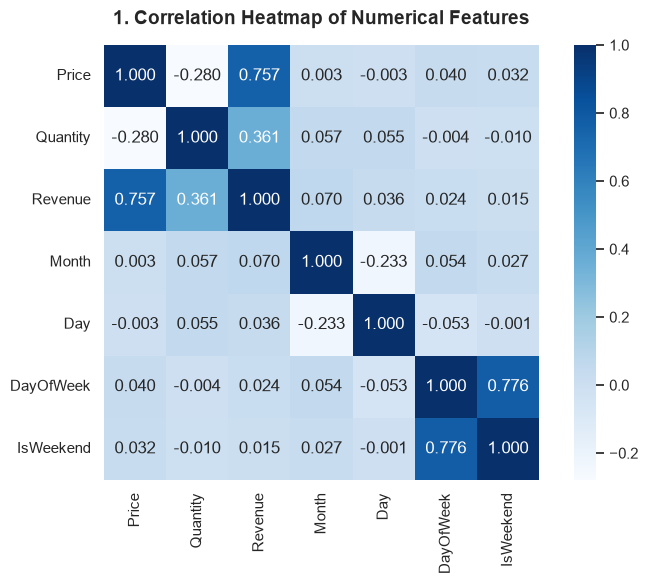

In [90]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='Blues', cbar=True, square=True)
plt.title('1. Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


การแปรผล

1. Price มีผลต่อยอดขายอย่างมีนัยยะสำคัญ ค่า r = 0.745 หมายถึง ราคาต่อหน่วยของสินค้า เป็นส่วนสำคัญที่ทำให้ยอดขายรวมสูง
2. จำนวนชิ้นที่ขายได้กับยอดขาย มีทิศทางเดียวกัน แต่ไม่มีผลมาก
3. Revenue ไม่ได้รับผลกระทบจากช่วงเวลา
ความสัมพันธ์อื่น ๆ ที่น่าาสนใจ
Price กับ Quantity มีผลเชิงลบ ตามความเป็นจริง เมื่อราคาสูงขึ้น จำนวนการซื้อจะลดลง
DayOfWeek กับ IsWeekend มีผลเชิงบวก เพราะ  IsWeekend มาจาก DayOfWeek ต้องระวังตอนทำโมเดล

มุมมองที่ 2: ยอดขายจำแนกตามประเภทสินค้า

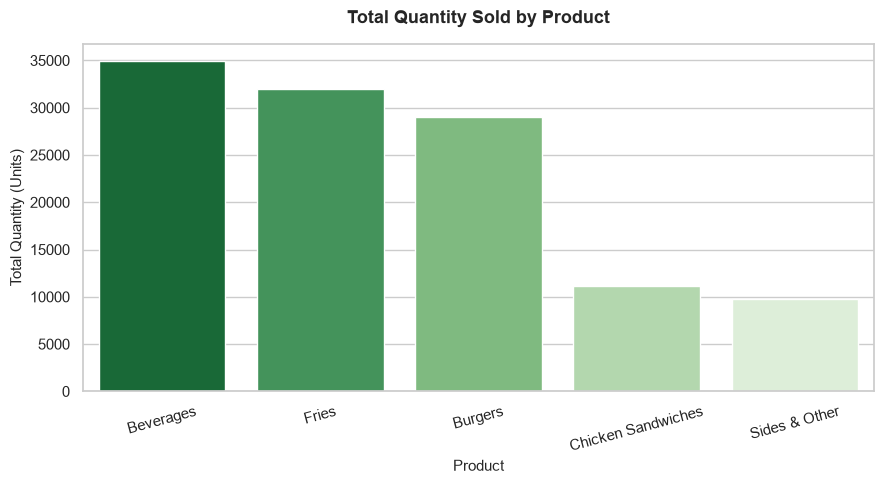

In [91]:
plt.figure(figsize=(9, 5))

# พล็อตกราฟแท่ง Total Quantity
ax = sns.barplot(
    data=product_qty,
    x='Product',
    y='Total_Quantity',
    hue='Product',
    palette='Greens_r',
    legend=False
)

plt.title('Total Quantity Sold by Product', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Product', fontsize=11)
plt.ylabel('Total Quantity (Units)', fontsize=11)
plt.xticks(rotation=15)


plt.tight_layout()
plt.show()

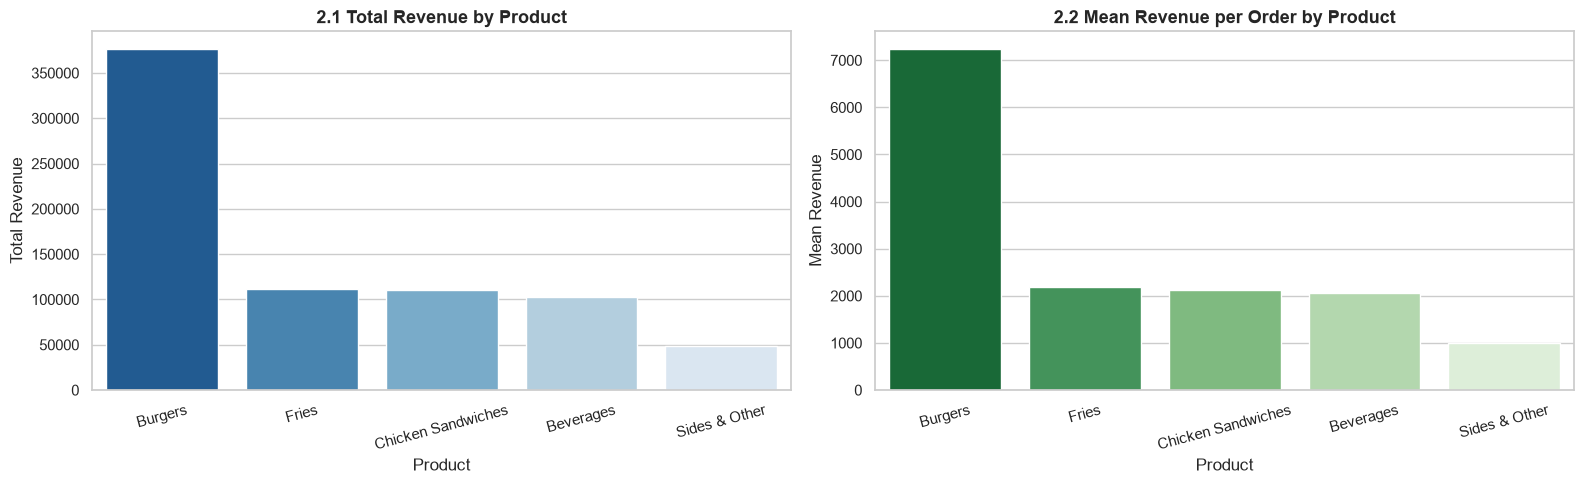

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=product_summary,
    x='Product',
    y='Total_Revenue',
    hue='Product',
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)
#ยอดขายรวมทั้งหมดแยกตามประเภทสินค้า
axes[0].set_title('2.1 Total Revenue by Product',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=15)

# มูลค่ายอดขายเฉลี่ยที่ได้รับต่อ 1 ออเดอร์ของสินค้าแต่ละประเภท
product_summary['Mean_Revenue'] = product_summary['Total_Revenue'] / product_summary['Order_Count']
product_mean = product_summary.sort_values(by='Mean_Revenue', ascending=False)
sns.barplot(
    data = product_mean,
    x = 'Product',
    y = 'Mean_Revenue',
    hue = 'Product',
    palette = 'Greens_r',
    legend = False,
    ax = axes[1]
)

axes[1].set_title('2.2 Mean Revenue per Order by Product', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Mean Revenue')
axes[1].tick_params(axis='x', rotation=15)

# จัดระยะห่าง
plt.tight_layout()

# แสดงกราฟ
plt.show()

แปรผล
กราฟยอดขายรวมทั้งหมดแยกตามประเภทสินค้า และ ยอดขายต่อออร์เดอร์ 1 ประเภท แสดงให้เห็นว่า Burgers เป็น เมนูที่ยอดขายสูงที่สุด  และถูกสั่งซื้อมากที่สุด แม้ว่า
จำนวนการสั่งซื้อ ของ Beverages และ Fries จะมีมากกว่า แต่ราคาต่อหน่วยต่ำ ทำให้ Burgers ที่่เป็นสินค้ามีราคาที่สูงพร้อมกับจำนวนการสั่งซื้อมีมาก ทำให้ยอดขายรวมสูงกว่า

มุมมองที่ 3: ยอดขายจำแนกตามช่องทางการซื้อ (Revenue by Purchase Type) 


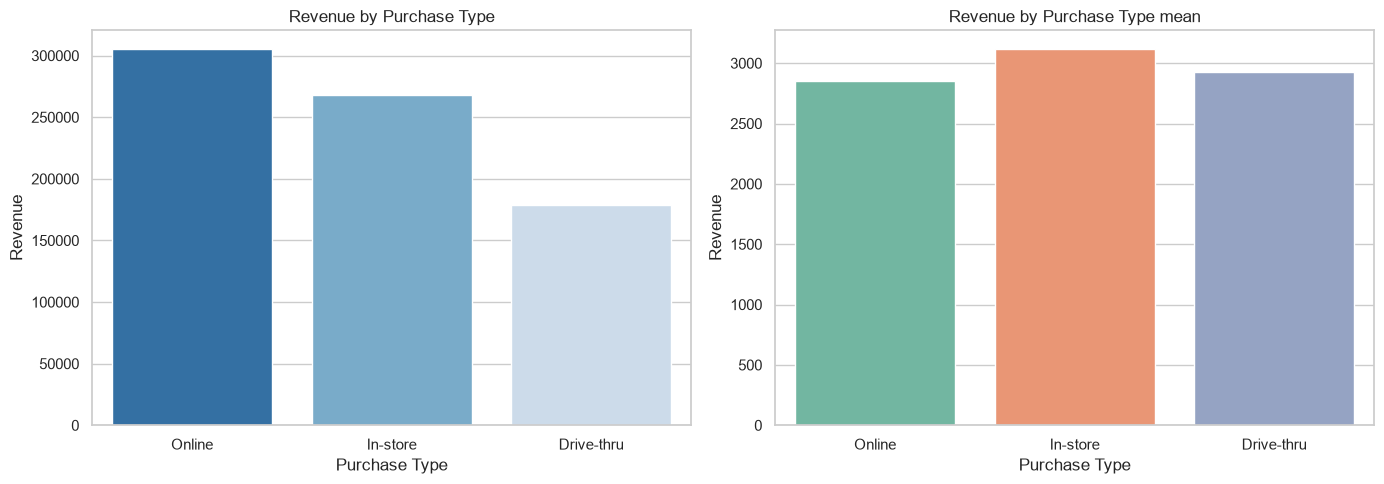

In [108]:
#สรุปยอดขายตามช่องทางการซื้อ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Revenue by Purchase Type')
ax = sns.barplot(
    data = CleanR,              # ชื่อ DataFrame หรือข้อมูลที่ต้องการนำมาพล็อต
    x = 'Purchase Type',       # ข้อมูลในแกน X (มักเป็นข้อมูลเชิงกลุ่ม/Categorical)
    y = 'Revenue',       # ข้อมูลในแกน Y (มักเป็นข้อมูลตัวเลข/Numerical)
    hue = 'Purchase Type',  # (Optional) คอลัมน์ที่ใช้จำแนกสีเพิ่ม
    palette = 'Blues_r',    # (Optional) โทนสีของกราฟ เช่น 'Blues_r', 'Set2', 'viridis'
    estimator = 'sum',      # (Optional) ฟังก์ชันคำนวณค่าแกน Y เช่น 'mean' (ค่าเริ่มต้น) หรือ 'sum'
    errorbar = None,        # (Optional) ปิด/เปิด เส้นขีดค่าความคลาดเคลื่อน (Confidence Interval)
    legend = False,          # (Optional) แสดงหรือซ่อนกล่องอธิบายสัญลักษณ์ (Legend)
    ax = axes[0]
)


axes[1].set_title('Revenue by Purchase Type mean')
ax = sns.barplot(
    data = CleanR,  
    x = 'Purchase Type',   
    y = 'Revenue', 
    hue = 'Purchase Type', 
    palette = 'Set2',  
    estimator = 'mean',
    errorbar =  None,
    legend = False,  
    ax = axes[1]
)

plt.tight_layout()

แปรผล
สำหรับกราฟแรก ยอดขายรวม ทำยอดขายผ่านช่องทาง online ได้สูงที่สุด เนื่องจากมีความถี่ในการสั่งซื้อจำนวนมาก (107 ครั้ง)
แต่ค่าเฉลี่ยยอดขายต่อรายการกลับเป็นช่องทาง ในร้านค้า เนื่องจากผู้สั่งซื้อจะสั่งซื้อต่อบิลในราคารวมที่สูงกว่า

มุมมองที่ 4 ยอดขายสินค้ากับเมืองต่าง ๆ

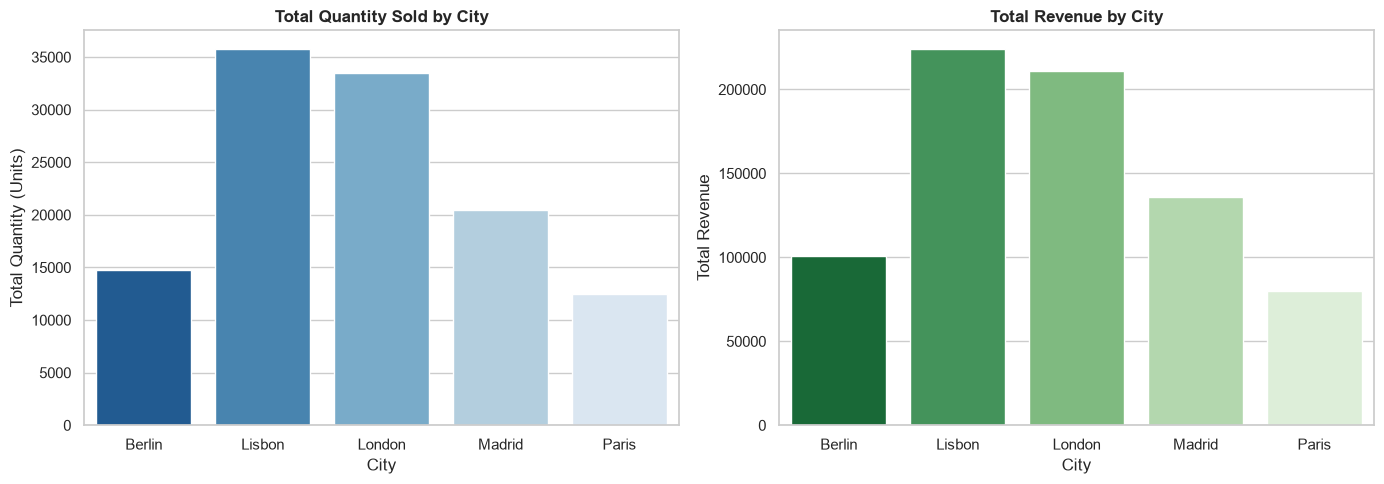

In [123]:
city_summary = CleanR.groupby('City').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1  จำนวนชิ้นรวมตามเมือง 
sns.barplot(
    data=city_summary,
    x='City',
    y='Total_Quantity',
    hue='City',
    palette='Blues_r',
    legend=False,
    ax=axes[0]  
)
axes[0].set_title('Total Quantity Sold by City', fontweight='bold', fontsize=12)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Quantity (Units)')

#กราฟที่ 2ยอดขายรวมตามเมือง 
sns.barplot(
    data=city_summary,
    x='City',
    y='Total_Revenue',
    hue='City',
    palette='Greens_r',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Total Revenue by City', fontweight='bold', fontsize=12)
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

แปรผล
จำนวนรวมที่ขายสินค้าได้ และยอดขายรวมที่ขายได้ ในแต่ละเมือง สอดคล้องกัน โดยมี Lisbon และ London ที่เป็นสองสาขาหลักที่ทำยอดขายได้มากที่สุด

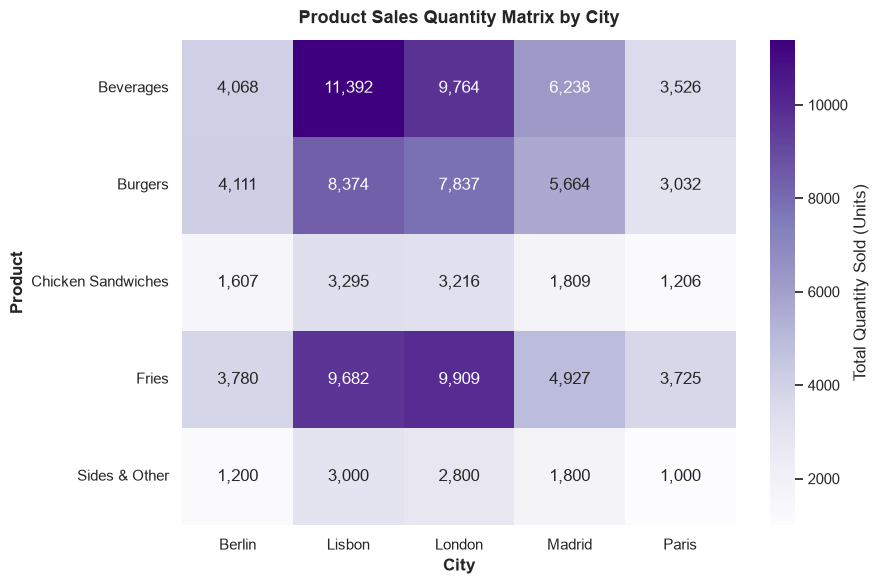

In [130]:
pivot = pd.crosstab(
    CleanR['Product'],
    CleanR['City'],
    values=CleanR['Quantity'],
    aggfunc='sum'
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='Purples',
    cbar_kws={'label': 'Total Quantity Sold (Units)'}
)

plt.title(
    'Product Sales Quantity Matrix by City',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.xlabel('City', fontweight='bold')
plt.ylabel('Product', fontweight='bold')

plt.tight_layout()
plt.show()

แปรผล
สินค้า Beverages  ในเมือง Lisbon ขายดีที่สุด ถัดมาภายในเมือง คือ Fries และ Burgers

สินค้า Sides and other ในเมือง Paris มีการขายได้น้อยที่สุด

ไม่มีการนำ Manager มาพิจารณาต่อ เนื่องจาก ผู้จัดกรแต่บละคนจะประจำอยู่ที่สาขแต่ละเมือง เท่านั้น ทำให้มีค่าเท่ากับร้านในแต่ละเมือง

#**Encoding**

In [131]:
from sklearn.preprocessing import StandardScaler

In [137]:
# คัดลอก DataFrame สำหรับทำโมเดล
res_encode = CleanR.copy()

# One-Hot Encoding
categorical_cols = ['Product', 'Purchase Type', 'Payment Method', 'City']
res_encode = pd.get_dummies(res_encode, columns = categorical_cols,
                                  drop_first = True, dtype = int)
# drop_first=True ลบcol แรก ใช้ Drive-thru เป็นค่าเปรียบเทียบ (Baseline): โมเดลจะดูว่าการซื้อแบบ In-store หรือ Online ได้ยอดขาย "เพิ่มขึ้นหรือลดลงเท่าไร เมื่อเทียบกับ Drive-thru"

res_encode.head()

,Order ID,Date,Price,Quantity,Manager,Month,Day,DayOfWeek,IsWeekend,Revenue,...,Product_Fries,Product_Sides & Other,Purchase Type_In-store,Purchase Type_Online,Payment Method_Credit Card,Payment Method_Gift Card,City_Lisbon,City_London,City_Madrid,City_Paris
0,10452,2022-11-07,3.49,573,Tom Jackson,11,7,0,0,1999.77,...,1,0,0,1,0,1,0,1,0,0
1,10453,2022-11-07,2.95,746,Pablo Perez,11,7,0,0,2200.70,...,0,0,0,1,0,1,0,0,1,0
2,10454,2022-11-07,4.99,200,Joao Silva,11,7,0,0,998.00,...,0,1,1,0,0,1,1,0,0,0
3,10455,2022-11-08,12.99,570,Walter Muller,11,8,1,0,7404.30,...,0,0,1,0,1,0,0,0,0,0
4,10456,2022-11-08,9.95,201,Walter Muller,11,8,1,0,1999.95,...,0,0,1,0,1,0,0,0,0,0


In [138]:
res_encode.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order ID                    254 non-null    int64         
 1   Date                        254 non-null    datetime64[us]
 2   Price                       254 non-null    float64       
 3   Quantity                    254 non-null    int64         
 4   Manager                     254 non-null    str           
 5   Month                       254 non-null    int32         
 6   Day                         254 non-null    int32         
 7   DayOfWeek                   254 non-null    int32         
 8   IsWeekend                   254 non-null    int64         
 9   Revenue                     254 non-null    float64       
 10  Product_Burgers             254 non-null    int64         
 11  Product_Chicken Sandwiches  254 non-null    int64         
 12  Produ

**เตรียมข้อมูลสำหรับทำModel**

In [142]:
# กำหนดตัวแปรอิสระ ใช้วิธีตัดข้อมูลมที่ไม่ใช้ออก
X = res_encode.drop(columns=['Order ID', 'Date', 'Revenue', 'Manager'], errors='ignore')

# กำหนดตัวแปรเป้าหมาย (y)
y = res_encode['Revenue']

print(" X Features : ", X.shape)
print(" y Target : ", y.shape)
print("=========================")

print("X Features List  : ", X.columns.tolist())
print("\n")
print("y Target Name    : ", y.name)

 X Features :  (254, 18)
 y Target :  (254,)
X Features List  :  ['Price', 'Quantity', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Product_Burgers', 'Product_Chicken Sandwiches', 'Product_Fries', 'Product_Sides & Other', 'Purchase Type_In-store', 'Purchase Type_Online', 'Payment Method_Credit Card', 'Payment Method_Gift Card', 'City_Lisbon', 'City_London', 'City_Madrid', 'City_Paris']


y Target Name    :  Revenue


**แบ่งข้อมูล Train/Test data Set**

In [ ]:
from sklearn.model_selection import train_test_split

In [143]:
# แบ่งข้อมูลเป็น Train (80%) และ Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,    
    random_state=42   
)

# แสดงขนาดของชุดข้อมูลเพื่อตรวจสอบความถูกต้อง
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (203, 18)
X_test shape  : (51, 18)
y_train shape : (203,)
y_test shape  : (51,)


**เริ่มต้น Training**